# Activity 1.1 : Introduction to Machine Learning

Objective(s):

This activity aims to introduce how to use the different toolsets  in machine learning.

Intended Learning Outcomes (ILOs):
* Demonstrate how to use different toolsets in machine learning.
* Demonstrate how to import, manipulate and analyze data using pandas and numpy.
* Demonstrate how to visualize data in graphs using matplotlib and seaborn


Resources:
* Jupyter Notebook
* Iris_Data.csv


Procedure:

The iris data set will be used for this activity. It is a well-known data set containing iris species and sepal and petal measurements.

Import the libraries and the dataset

In [ ]:
#import the libraries
import pandas as pd
import numpy as np

# import the dataset
data = pd.read_csv('Iris_Data.csv')
#check the content of the dataframe
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Determine the following:
* The number of data points (rows).
* The column names.
* The data types for each column.

In [ ]:
#the number of datapoints
print(data.shape[0])

#the column names
print(data.columns.tolist())

#the data types for each column
print(data.dtypes)

150
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


Examine the species names and note that they all begin with 'Iris-'. Remove this portion of the name so the species name is shorter.

In [ ]:
#remove the 'Iris-' portion of the name
data['species'] = data.species.str.replace('Iris-', '')
data.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Determine the following:
* The number of each species present.
* The mean, median, and quantiles and ranges (max-min) for each petal and sepal measurement.

In [ ]:
#the number of each species present
data.species.value_counts()

# the mean, median and quartiles and ranges
stats_df = data.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

out_fields = ['mean','25%','50%','75%', 'range']
stats_df = stats_df.loc[out_fields]
stats_df.rename({'50%': 'median'}, inplace=True)
stats_df



,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.054,3.758667,1.198667
25%,5.100000,2.800,1.600000,0.300000
median,5.800000,3.000,4.350000,1.300000
75%,6.400000,3.300,5.100000,1.800000
range,3.600000,2.400,5.900000,2.400000


Calculate the following for each species in a separate dataframe:
* The mean of each measurement (sepal_length, sepal_width, petal_length, and petal_width).
* The median of each of these measurements.

In [ ]:
# The mean calculation
data.groupby('species').mean()



,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [ ]:
# The median calculation
data.groupby('species').median()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


In [ ]:
from pprint import pprint

agg_dict = {field: ['mean', 'median'] for field in data.columns if field != 'species'}
agg_dict['petal_length'] = 'max'
pprint(agg_dict)
data.groupby('species').agg(agg_dict)

{'petal_length': 'max',
 'petal_width': ['mean', 'median'],
 'sepal_length': ['mean', 'median'],
 'sepal_width': ['mean', 'median']}


sepal_length        sepal_width        petal_length petal_width  \
                   mean median        mean median          max        mean   
species                                                                      
setosa            5.006    5.0       3.418    3.4          1.9       0.244   
versicolor        5.936    5.9       2.770    2.8          5.1       1.326   
virginica         6.588    6.5       2.974    3.0          6.9       2.026   

                   
           median  
species            
setosa        0.2  
versicolor    1.3  
virginica     2.0

Make a scatter plot of `sepal_length` vs `sepal_width` using Matplotlib. Label the axes and give the plot a title.

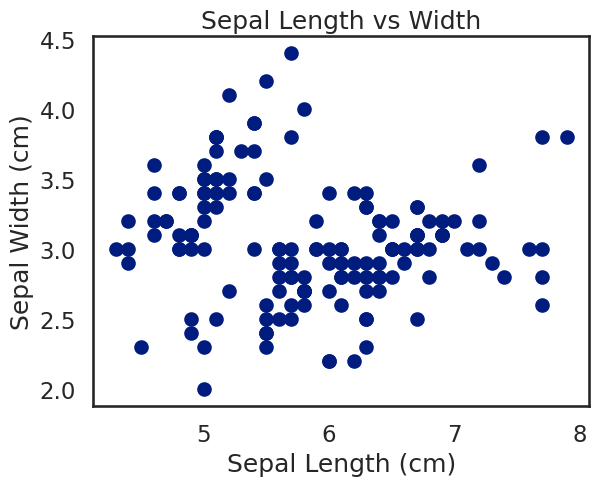

In [ ]:
#Scatter plot of sepal_length versus sepal_width using Matplotlib

import matplotlib.pyplot as plt
%matplotlib inline
# A simple scatter plot with Matplotlib
ax = plt.axes()

ax.scatter(data.sepal_length, data.sepal_width)

# Label the axes
ax.set(xlabel='Sepal Length (cm)',
       ylabel='Sepal Width (cm)',
       title='Sepal Length vs Width');


Interpret the result of the scatter plot.

- The scatter plot above shown the relationship and distribution of data points in the Iris dataset. It mainly presented the usual sepal length and width of Iris flowers, usually sitting between 5.5 to 7 centimeters long and 2.5 to 3.5 centimeters wide.

Make a histogram of any one of the four features. Label axes and title it as appropriate. What is the function of the histogram ?

- The histogram manly shows the frequency of data points in the dataset. In other words, it shows how many times a certain value appeared in a dataset.

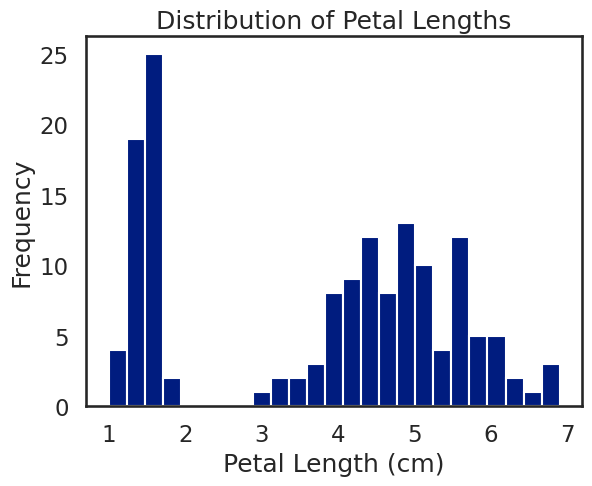

In [ ]:
#histogram
ax = plt.axes()
ax.hist(data.petal_length, bins=25);

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

Make a boxplot of each petal and sepal measurement. What is the function of the boxplot?

- The boxplot shows the interquartile range of the dataset, showing the median, quartiles, and range. It can also be used to locate the outliers in the dataset, essential in balancing the dataset.

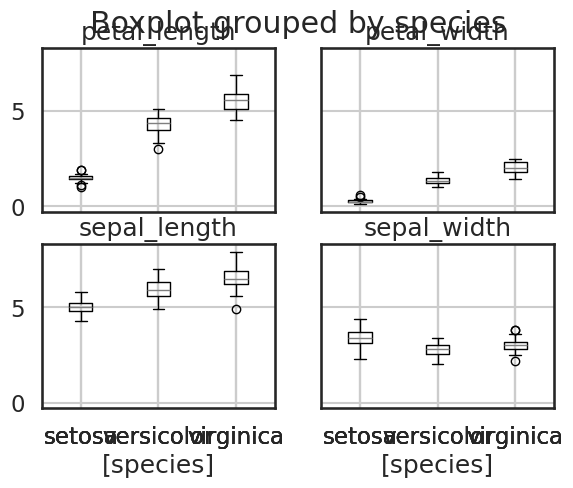

In [ ]:
#boxplot
data.boxplot(by='species');

Make a single boxplot where the features are separated in the x-axis and species are colored with different hues.

In [ ]:
#single boxplot
plot_data = (data
             .set_index('species')
             .stack()
             .to_frame()
             .reset_index()
             .rename(columns={0:'size', 'level_1':'measurement'})
            )

plot_data.head()

,species,measurement,size
0,setosa,sepal_length,5.1
1,setosa,sepal_width,3.5
2,setosa,petal_length,1.4
3,setosa,petal_width,0.2
4,setosa,sepal_length,4.9


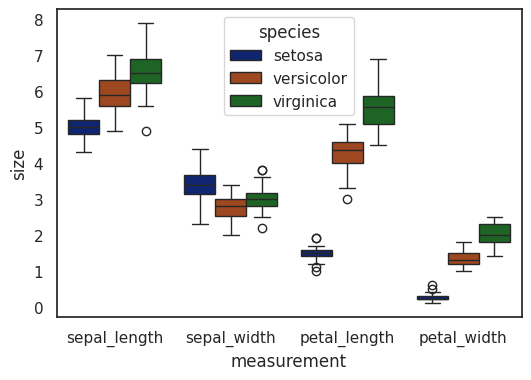

In [ ]:
import seaborn as sns
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
sns.boxplot(x='measurement', y='size',
            hue='species', data=plot_data);

Make a pairplot with Seaborn to examine the correlation between each of the measurements.

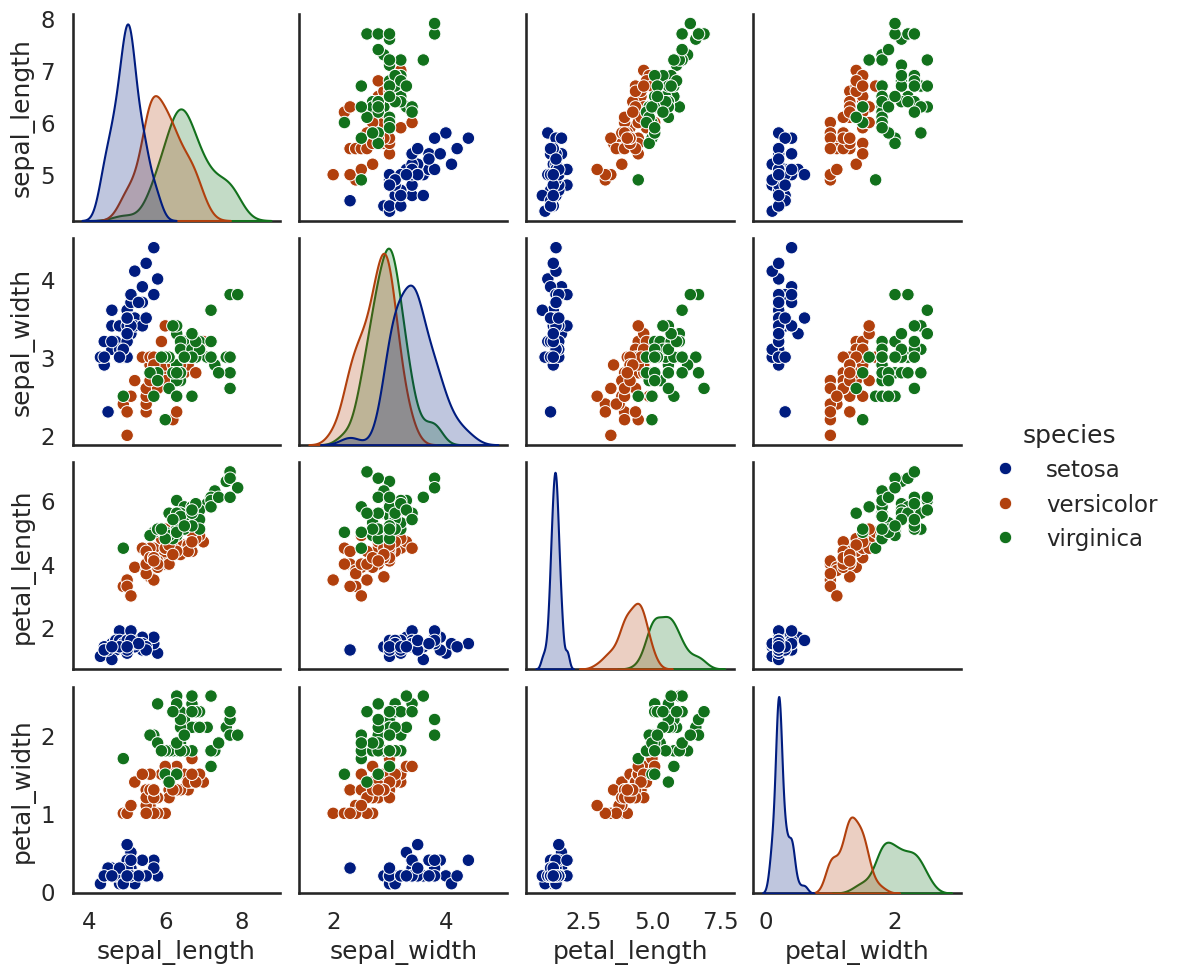

In [ ]:
#pair plot
sns.set_context('talk')
sns.pairplot(data, hue='species');



Interpret the result of correlation using the pairplot

- The pair plot presented the distribution and correlation of measurements of each species of the Iris flower with the use of a scatter plot and kde plot. In terms of their similarities, setosa, versicolor, and virginica have similar sepal width. On the other hand, versicolor and virginica are similar in terms of their sepal length, petal length, and petal width, but virginica usually have larger measurements. The petals of Setosa may also appear smaller compared to the other species.

Supplementary Activity:
* Choose your own dataset
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values.
* Perform descriptive statistics such as mean, median and mode
* Compare and analyze your data using data visualization

# NBA Players Data Analysis

Link: https://www.kaggle.com/datasets/justinas/nba-players-data/code

## Extract

In [ ]:
# type your code here

# Import dataset
nba_df = pd.read_csv('all_seasons.csv')
nba_df.head()

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [ ]:
# number of datapoints
print(nba_df.shape[0])

# column names
print(nba_df.columns.tolist())

# data types for each column
print(nba_df.dtypes)

12844
['Unnamed: 0', 'player_name', 'team_abbreviation', 'age', 'player_height', 'player_weight', 'college', 'country', 'draft_year', 'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season']
Unnamed: 0             int64
player_name           object
team_abbreviation     object
age                  float64
player_height        float64
player_weight        float64
college               object
country               object
draft_year            object
draft_round           object
draft_number          object
gp                     int64
pts                  float64
reb                  float64
ast                  float64
net_rating           float64
oreb_pct             float64
dreb_pct             float64
usg_pct              float64
ts_pct               float64
ast_pct              float64
season                object
dtype: object


## Transform

In [ ]:
# remove unnecessary columns
nba_df = nba_df.drop('Unnamed: 0', axis=1)
nba_df.head()

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [ ]:
# remove empty values
nba_df = nba_df.dropna()
nba_df.head()

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


## Load

In [ ]:
# mean, median, quartiles, and ranges
team_stats_df = nba_df.describe()
team_stats_df.loc['range'] = team_stats_df.loc['max'] - team_stats_df.loc['min']

out_fields = ['mean','25%','50%','75%', 'range']
team_stats_df = team_stats_df.loc[out_fields]
team_stats_df.rename({'50%': 'median'}, inplace=True)
team_stats_df

,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
mean,27.182712,199.754848,99.611030,50.664695,8.074131,3.445551,1.824923,-2.308517,0.052927,0.13745,0.183053,0.510913,0.132562
25%,24.000000,193.040000,90.718400,30.000000,3.500000,1.700000,0.600000,-6.500000,0.021000,0.09400,0.148000,0.479000,0.066000
median,26.000000,200.660000,99.790240,56.000000,6.600000,2.900000,1.200000,-1.400000,0.039000,0.12600,0.179000,0.523000,0.104000
75%,30.000000,205.740000,108.862080,73.000000,11.300000,4.500000,2.400000,3.000000,0.081000,0.17500,0.215000,0.561000,0.180000
range,25.000000,68.580000,102.965384,84.000000,36.100000,16.300000,11.700000,550.000000,0.600000,1.00000,0.595000,1.500000,1.000000


In [ ]:
# mean
nba_df.groupby('team_abbreviation').mean(numeric_only=True)

,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
team_abbreviation,,,,,,,,,,,,,
ATL,26.694595,200.330486,99.721588,48.551351,7.636757,3.244595,1.657568,-3.450270,0.053262,0.135324,0.179654,0.506351,0.127354
BKN,27.154286,199.339200,99.051533,46.937143,8.912000,3.617143,2.045143,-3.218286,0.044520,0.141617,0.184069,0.525577,0.140714
BOS,26.589812,199.114209,100.003051,52.538874,8.368097,3.428150,1.938874,-0.514477,0.052509,0.135997,0.179812,0.525126,0.136542
CHA,25.969349,199.011111,98.266981,49.858238,8.059387,3.301916,1.790805,-5.034483,0.046854,0.135517,0.185383,0.509391,0.137590
CHH,29.045977,200.572414,101.672386,51.137931,7.800000,3.396552,1.834483,-4.219540,0.062356,0.140034,0.189172,0.477598,0.140517
CHI,27.049315,199.142959,98.230629,52.342466,8.315616,3.539726,1.987671,-1.716712,0.051348,0.133373,0.184984,0.499918,0.142567
CLE,26.972452,199.309532,99.630296,48.672176,7.395868,3.251240,1.694490,-2.845730,0.051116,0.135163,0.180107,0.500708,0.129512
DAL,28.288515,199.044930,98.216009,50.123249,7.494398,3.184874,1.764426,-1.658543,0.051591,0.132308,0.181731,0.508034,0.128728
DEN,27.021978,199.271374,98.342235,51.785714,8.231044,3.518956,1.878846,-2.796703,0.055610,0.135016,0.184008,0.519777,0.140297


In [ ]:
# median
nba_df.groupby('team_abbreviation').median(numeric_only=True)

,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
team_abbreviation,,,,,,,,,,,,,
ATL,26.0,201.93,99.790240,54.0,5.75,2.60,1.10,-3.20,0.0430,0.1250,0.1750,0.5190,0.0975
BKN,27.0,198.12,97.522280,50.0,7.30,3.30,1.50,-2.30,0.0270,0.1270,0.1770,0.5410,0.1090
BOS,26.0,200.66,99.790240,58.0,6.60,3.00,1.40,0.00,0.0370,0.1330,0.1760,0.5340,0.1110
CHA,25.0,200.66,97.522280,53.0,7.10,3.00,1.20,-3.80,0.0360,0.1260,0.1860,0.5180,0.1110
CHH,30.0,203.20,99.790240,52.0,5.90,2.70,1.20,1.20,0.0460,0.1240,0.1900,0.5120,0.1070
CHI,26.0,200.66,97.522280,58.0,6.90,3.00,1.50,-1.80,0.0370,0.1210,0.1800,0.5110,0.1220
CLE,26.0,200.66,99.336648,54.0,5.90,2.70,1.20,-2.80,0.0360,0.1180,0.1740,0.5170,0.1010
DAL,28.0,200.66,97.522280,56.0,6.60,2.70,1.20,0.00,0.0380,0.1240,0.1820,0.5230,0.0970
DEN,26.0,200.66,99.336648,58.0,7.30,2.90,1.30,-1.60,0.0430,0.1250,0.1850,0.5260,0.1090


### League-Wide Stats

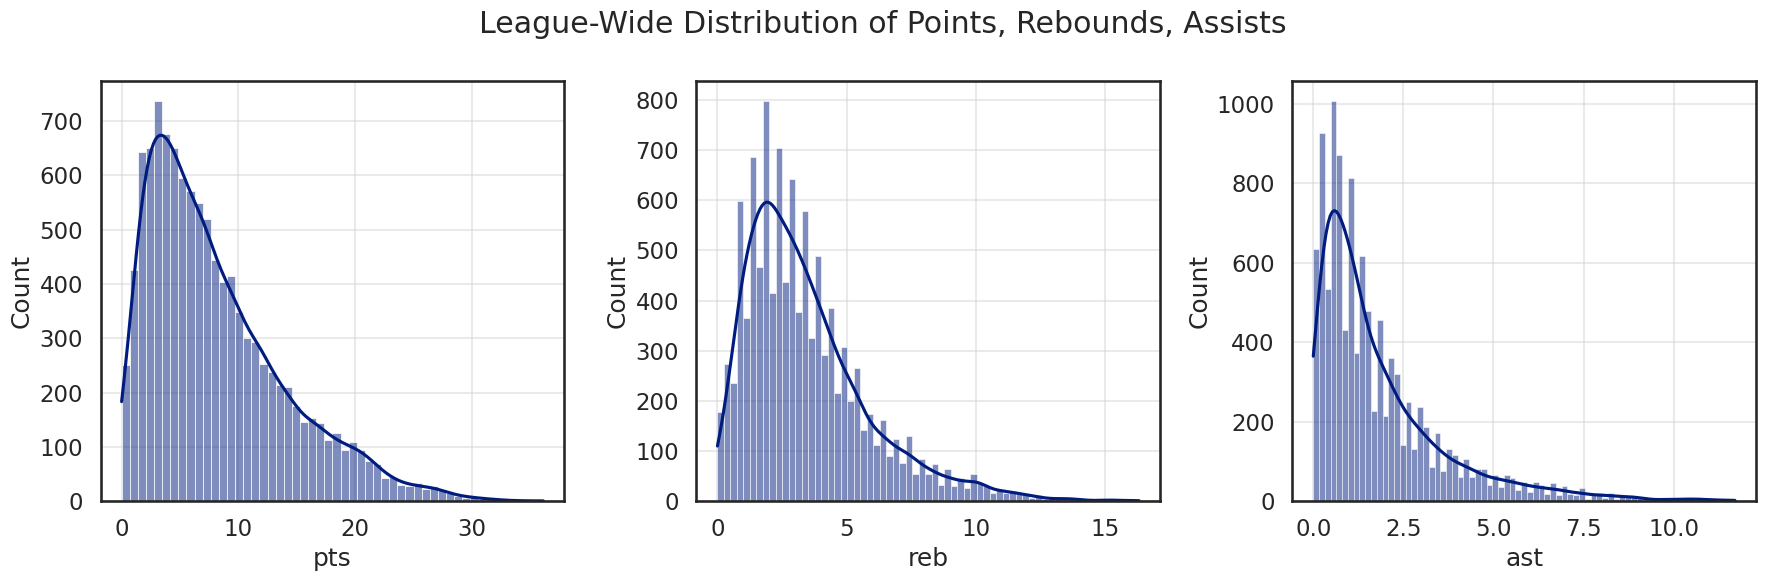

In [ ]:
# League-Wide Distribution of Points, Rebounds, Assists
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
key_metrics = ['pts', 'reb', 'ast']

for ax, metric in zip(axes, key_metrics):
    sns.histplot(nba_df[metric], kde=True, ax=ax)
    ax.set_xlabel(metric)
    ax.grid(True, alpha=0.4)

plt.suptitle("League-Wide Distribution of Points, Rebounds, Assists")
plt.tight_layout()
plt.show()

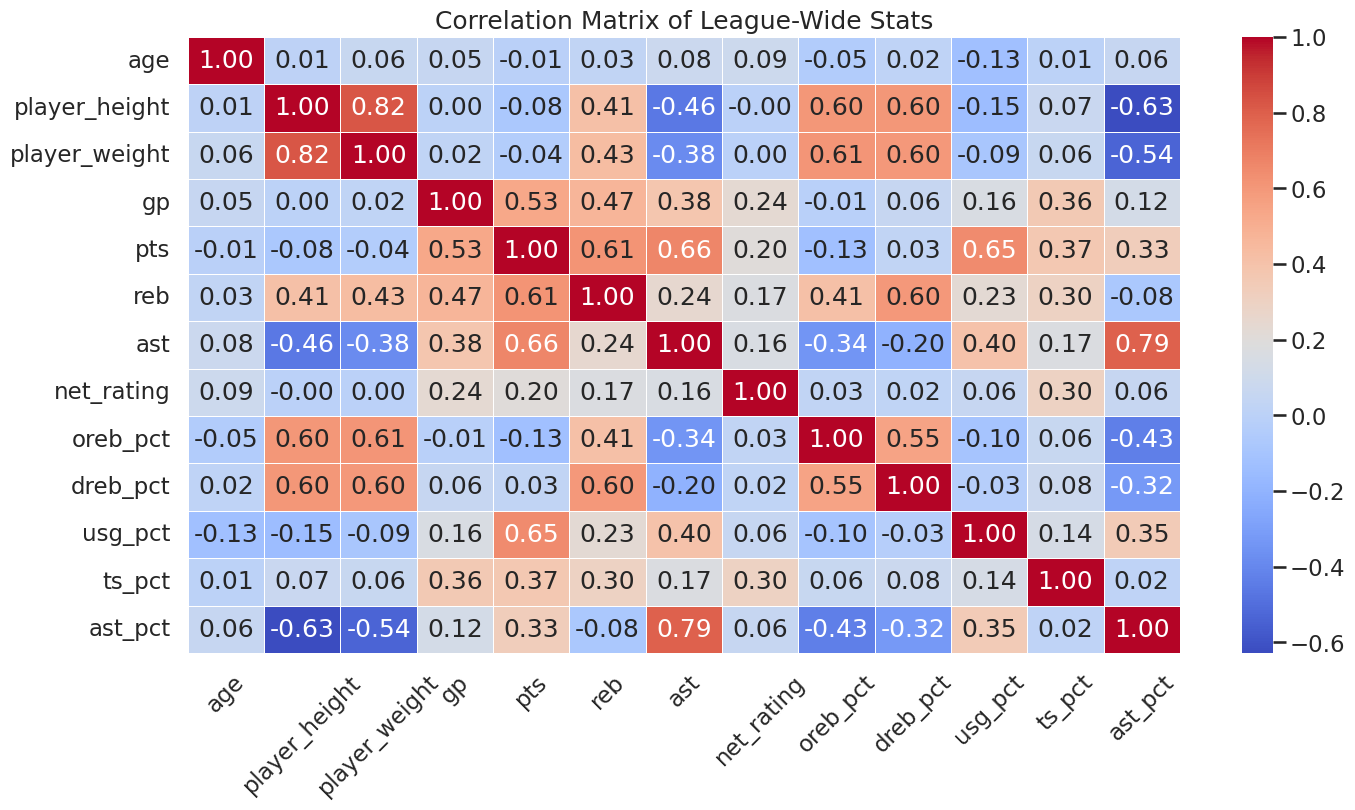

In [ ]:
# Correlation Matrix of League-Wide Stats
correlation_matrix = nba_df.select_dtypes(exclude=['object']).corr()

plt.figure(figsize=(16, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of League-Wide Stats')
plt.xticks(rotation=45)
plt.show()

### Team Stats

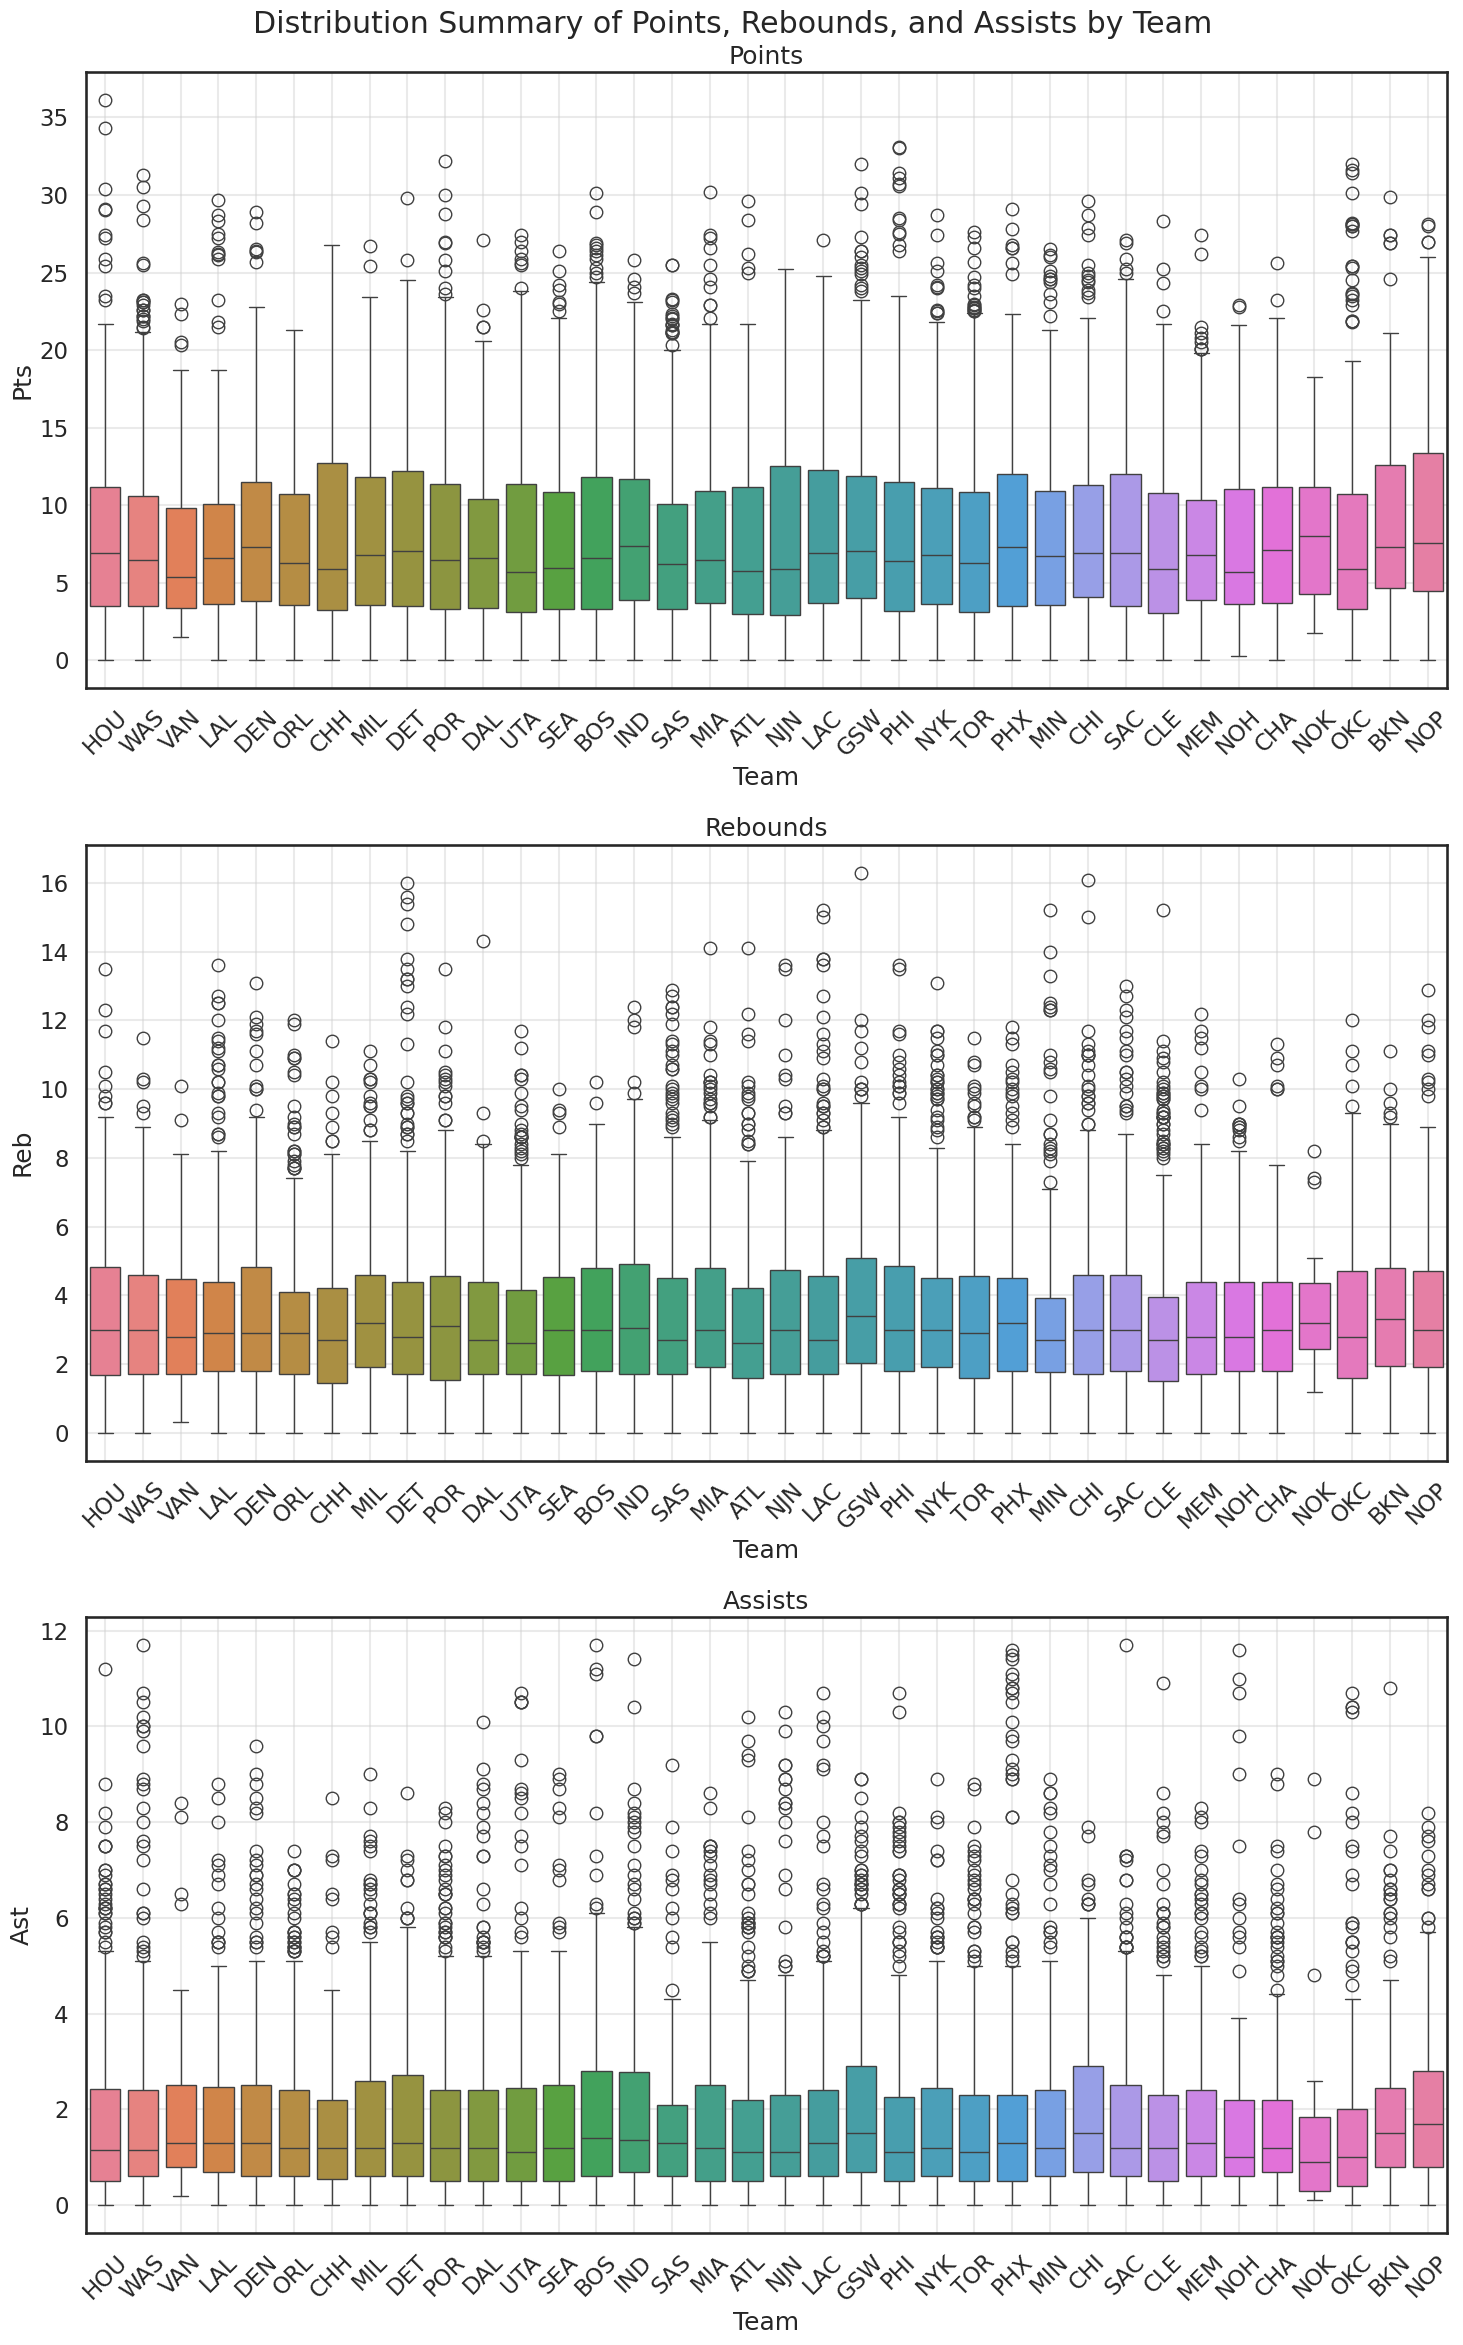

In [ ]:
# Distribution Summary of Points, Rebounds, and Assists by Team
fig, axes = plt.subplots(3, 1, figsize=(15, 24))
key_metrics = ['pts', 'reb', 'ast']
titles = ['Points', 'Rebounds', 'Assists']

for ax, metric, title in zip(axes, key_metrics, titles):
    sns.boxplot(x='team_abbreviation', y=metric, data=nba_df, hue='team_abbreviation', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Team')
    ax.set_ylabel(metric.capitalize())
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.4)

plt.suptitle("Distribution Summary of Points, Rebounds, and Assists by Team")
plt.tight_layout()
plt.show()

In [ ]:
#

### Best Players Stats

In [ ]:
# Players With Highest Season Points
nba_df.sort_values(by='pts', ascending=False).head(10)

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
10227,James Harden,HOU,29.0,195.58,99.79024,Arizona State,USA,2009,1,3,...,36.1,6.6,7.5,6.3,0.023,0.157,0.396,0.616,0.394,2018-19
10634,James Harden,HOU,30.0,195.58,99.79024,Arizona State,USA,2009,1,3,...,34.3,6.6,7.5,5.8,0.026,0.139,0.356,0.626,0.366,2019-20
12839,Joel Embiid,PHI,29.0,213.36,127.00576,Kansas,Cameroon,2014,1,3,...,33.1,10.2,4.2,8.8,0.057,0.243,0.370,0.655,0.233,2022-23
4302,Allen Iverson,PHI,31.0,182.88,74.84268,Georgetown,USA,1996,1,1,...,33.0,3.2,7.4,0.8,0.016,0.071,0.354,0.543,0.331,2005-06
12564,Damian Lillard,POR,32.0,187.96,88.45044,Weber State,USA,2012,1,6,...,32.2,4.8,7.3,2.1,0.022,0.112,0.331,0.645,0.338,2022-23
11537,Stephen Curry,GSW,33.0,190.50,83.91452,Davidson,USA,2009,1,7,...,32.0,5.5,5.8,4.6,0.013,0.135,0.331,0.655,0.283,2020-21
8013,Kevin Durant,OKC,25.0,205.74,108.86208,Texas,USA,2007,1,2,...,32.0,7.4,5.5,8.0,0.022,0.184,0.327,0.635,0.259,2013-14
9309,Russell Westbrook,OKC,28.0,190.50,90.71840,UCLA,USA,2008,1,4,...,31.6,10.7,10.4,3.3,0.053,0.279,0.408,0.554,0.543,2016-17
12442,Shai Gilgeous-Alexander,OKC,24.0,198.12,88.45044,Kentucky,Canada,2018,1,11,...,31.4,4.8,5.5,2.7,0.023,0.109,0.318,0.626,0.249,2022-23
2607,Allen Iverson,PHI,27.0,182.88,74.84268,Georgetown,USA,1996,1,1,...,31.4,4.5,5.5,5.1,0.019,0.093,0.371,0.489,0.266,2001-02


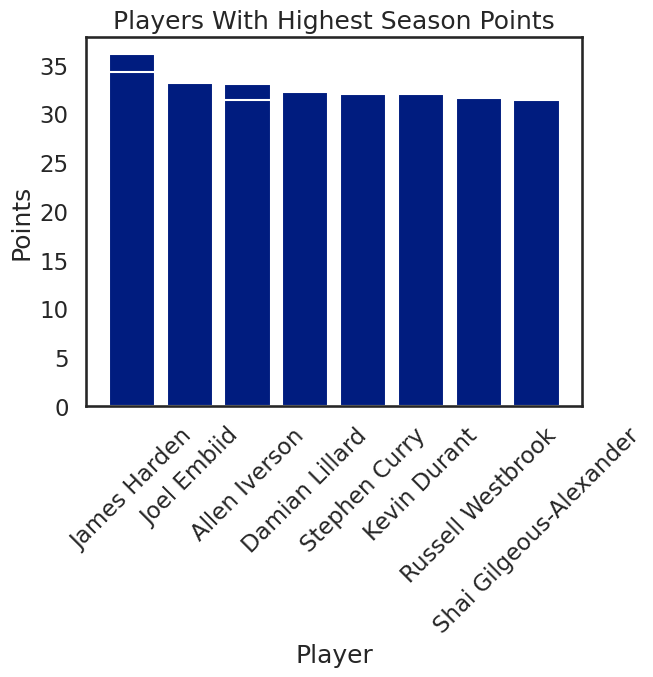

In [ ]:
# Players With Highest Season Points
plt.bar(nba_df.sort_values(by='pts', ascending=False).head(10)['player_name'], nba_df.sort_values(by='pts', ascending=False).head(10)['pts'])
plt.title('Players With Highest Season Points')
plt.xlabel('Player')
plt.ylabel('Points')
plt.xticks(rotation=45)
plt.show()

#Conclusion
The hands-on activity highlights the introduction in machine learning. It is important to remember that understanding your data is the first step of machine learning. The concept of "Trash In, Trash Out" is a significant reminder in machine learning as it highlights the importance of data preprocessing when training models.<br><br>
In this activity, we reviewed how to use pandas and numpy libraries to clearly explain and present data, which are essential skills we learned on the previous data science course. We explored on the Iris dataset, where we understood how to differentiate the different species of Iris flowers using the measurements of their sepals and petals. We used its data in order to find metrics like mean, median, and distribution of data in order to recognize the pattern in differentiating Iris flowers. I was able to regain my knowledge in the ETL process after accomplishing it.<br><br>
In the supplementary activity, I analyzed the NBA Players dataset to generate insights regarding the league-wide statistics, team statistics, and player statistics. I mainly used the points, rebounds, and assists data as they serve as the key metrics in the game of basketball. One of the challenges I encountered while doing it is finding ways to present their data as basketball data are complex, having multiple data categories.<br><br>